# GoEmotions — EDA, Cleaning & Preprocessing

**Dataset**: Google GoEmotions — 58,000+ Reddit comments, 27 emotion labels + neutral  
**Role in EmoCare**: Text emotion classification backbone  
**Format**: HuggingFace Arrow format (train / validation / test splits)  

### Notebook Sections
0. Imports & Paths  
1. Load Raw Data  
2. EDA — Shape, Schema, Label Distribution, Sample Review  
3. Cleaning — Duplicates, Nulls, Multi-label handling  
4. Preprocessing — Normalise text, map labels, train/val/test split  
5. Save to `data/processed/`

## 0. Imports & Paths

In [1]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk

# ── Project paths ────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_DIR      = os.path.join(PROJECT_ROOT, 'data', 'raw', 'goemotions')
INTERIM_DIR  = os.path.join(PROJECT_ROOT, 'data', 'interim')
PROCESSED_DIR= os.path.join(PROJECT_ROOT, 'data', 'processed')
os.makedirs(INTERIM_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Raw data     : {RAW_DIR}')
print(f'Pandas version: {pd.__version__}')

Project root : D:\EmoCare
Raw data     : D:\EmoCare\data\raw\goemotions
Pandas version: 3.0.5


## 1. Load Raw Data

In [2]:
# GoEmotions is stored as HuggingFace Arrow dataset
dataset = load_from_disk(RAW_DIR)
print(dataset)
print()
print('Features:', dataset['train'].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Features: {'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [3]:
# Convert all splits to pandas DataFrames for EDA
df_train = dataset['train'].to_pandas()
df_val   = dataset['validation'].to_pandas()
df_test  = dataset['test'].to_pandas()

print(f'Train : {df_train.shape}')
print(f'Val   : {df_val.shape}')
print(f'Test  : {df_test.shape}')
df_train.head()

Train : (43410, 3)
Val   : (5426, 3)
Test  : (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


## 2. EDA — Shape, Schema, Label Distribution, Samples

In [4]:
# Schema & dtypes
print('=== Train Schema ===')
print(df_train.dtypes)
print()
print('=== Null counts ===')
print(df_train.isnull().sum())

=== Train Schema ===
text         str
labels    object
id           str
dtype: object

=== Null counts ===
text      0
labels    0
id        0
dtype: int64


In [5]:
# GoEmotions label names (28 emotions including neutral)
LABEL_NAMES = dataset['train'].features['labels'].feature.names
print(f'Number of label classes: {len(LABEL_NAMES)}')
print('Labels:', LABEL_NAMES)

Number of label classes: 28
Labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


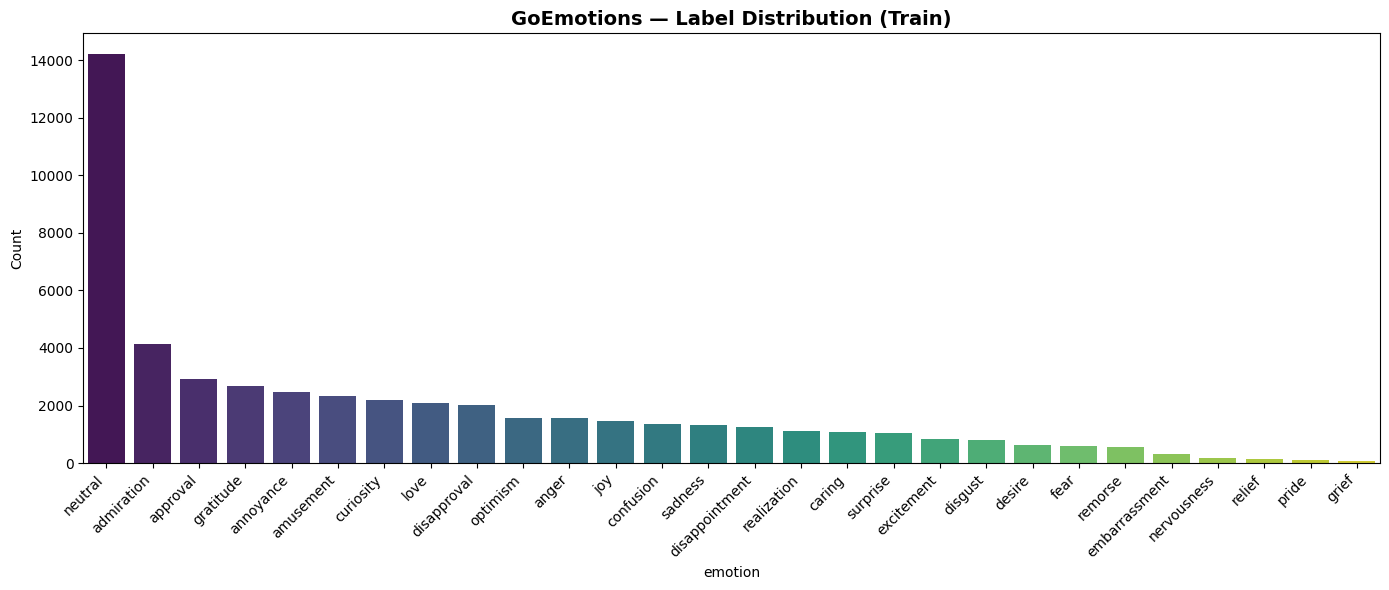

           emotion  count
0          neutral  14219
1       admiration   4130
2         approval   2939
3        gratitude   2662
4        annoyance   2470
5        amusement   2328
6        curiosity   2191
7             love   2086
8      disapproval   2022
9         optimism   1581
10           anger   1567
11             joy   1452
12       confusion   1368
13         sadness   1326
14  disappointment   1269
15     realization   1110
16          caring   1087
17        surprise   1060
18      excitement    853
19         disgust    793
20          desire    641
21            fear    596
22         remorse    545
23   embarrassment    303
24     nervousness    164
25          relief    153
26           pride    111
27           grief     77


In [6]:
# Label frequency — multi-label: explode lists into individual counts
from collections import Counter

label_counts = Counter()
for labels in df_train['labels']:
    for l in labels:
        label_counts[LABEL_NAMES[l]] += 1

label_df = pd.DataFrame(label_counts.most_common(), columns=['emotion', 'count'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=label_df, x='emotion', y='count', palette='viridis', ax=ax)
ax.set_title('GoEmotions — Label Distribution (Train)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(INTERIM_DIR, 'goemotions_label_dist.png'), dpi=150)
plt.show()
print(label_df)

labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


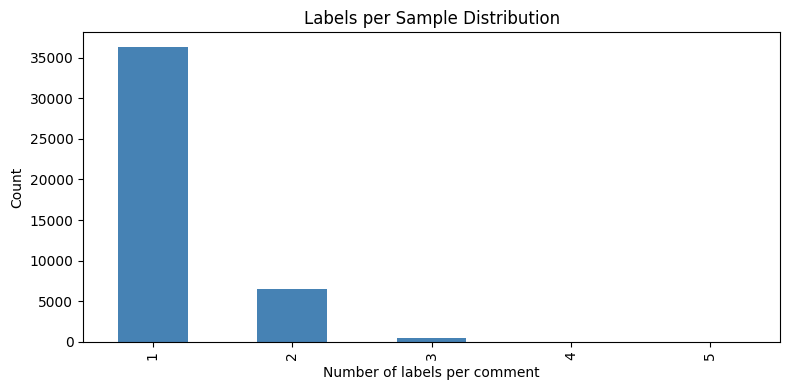

In [7]:
# Multi-label count distribution — how many labels per sample?
label_count_per_sample = df_train['labels'].apply(len)
print(label_count_per_sample.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
label_count_per_sample.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Labels per Sample Distribution')
ax.set_xlabel('Number of labels per comment')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

count    43410.000000
mean        68.400875
std         36.721898
min          2.000000
25%         38.000000
50%         65.000000
75%         96.000000
max        703.000000
Name: text_len, dtype: float64


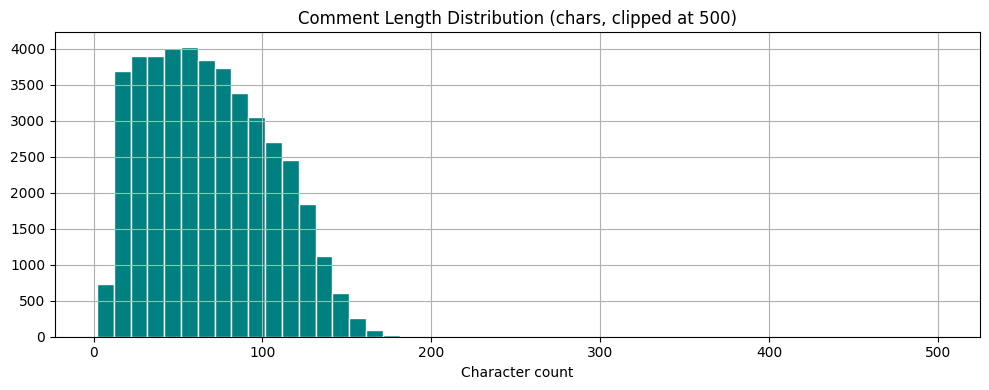

In [8]:
# Text length distribution
df_train['text_len'] = df_train['text'].str.len()

print(df_train['text_len'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df_train['text_len'].clip(upper=500).hist(bins=50, ax=ax, color='teal', edgecolor='white')
ax.set_title('Comment Length Distribution (chars, clipped at 500)')
ax.set_xlabel('Character count')
plt.tight_layout()
plt.show()

In [9]:
# Sample review — display a few examples per emotion
for emotion_idx in [0, 5, 10, 15, 20]:
    emo_name = LABEL_NAMES[emotion_idx]
    samples = df_train[df_train['labels'].apply(lambda x: emotion_idx in x)]['text'].head(2).tolist()
    print(f'\n[{emo_name}]')
    for s in samples:
        print(f'  → {s[:120]}')


[admiration]
  → Damn youtube and outrage drama is super lucrative for reddit
  → Famous for his 3-4 Defense

[caring]
  → R/sleeptrain Might be time for some sleep training. Take a look and try to feel out what's right for your family.
  → Good for #70 to console the poor guy



[disapproval]
  → I wouldn't let a sweet potato dictate decisions, ever.
  → This isn't really wholesome

[gratitude]
  → Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝
  → Thank you friend



[optimism]
  → We need more boards and to create a bit more space for [NAME]. Then we’ll be good.
  → It's true though. He either gets no shirt and freezes to death or wears a stupid looking butchers cape. I hope he gets s


## 3. Cleaning — Duplicates, Nulls, Multi-label handling

In [10]:
# Concatenate all splits for cleaning (re-split later after cleaning)
df_all = pd.concat([
    df_train.assign(split='train'),
    df_val.assign(split='val'),
    df_test.assign(split='test')
], ignore_index=True)

print(f'Total rows before cleaning: {len(df_all)}')

Total rows before cleaning: 54263


In [11]:
# 3a. Drop exact text duplicates (keep first)
n_before = len(df_all)
df_all = df_all.drop_duplicates(subset=['text'], keep='first')
print(f'Duplicates removed: {n_before - len(df_all)} | Remaining: {len(df_all)}')

Duplicates removed: 269 | Remaining: 53994


In [12]:
# 3b. Drop null / empty text
n_before = len(df_all)
df_all = df_all[df_all['text'].notna() & (df_all['text'].str.strip() != '')]
print(f'Empty text removed: {n_before - len(df_all)} | Remaining: {len(df_all)}')

Empty text removed: 0 | Remaining: 53994


In [13]:
# 3c. Multi-label strategy — for EmoCare we use the PRIMARY label (first/most common)
# Rationale: downstream model is fine-tuned MentalBERT for single-label classification;
# multi-label setup adds complexity without clear benefit for risk-tier fusion.
# We keep multi-label info in a separate column for reference.
df_all['label_primary']   = df_all['labels'].apply(lambda x: x[0] if len(x) > 0 else -1)
df_all['label_all_names'] = df_all['labels'].apply(lambda x: [LABEL_NAMES[i] for i in x])
df_all['label_name']      = df_all['label_primary'].apply(lambda x: LABEL_NAMES[x] if x >= 0 else 'unknown')

# Drop rows with no valid label
df_all = df_all[df_all['label_primary'] >= 0]
print(f'Rows after label filtering: {len(df_all)}')
df_all[['text', 'label_name', 'label_all_names']].head(5)

Rows after label filtering: 53994


,text,label_name,label_all_names
0,My favourite food is anything I didn't have to...,neutral,[neutral]
1,"Now if he does off himself, everyone will thin...",neutral,[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,anger,[anger]
3,To make her feel threatened,fear,[fear]
4,Dirty Southern Wankers,annoyance,[annoyance]


## 4. Preprocessing — Text Normalisation, Label Grouping, Split

In [14]:
import re

def clean_text(text: str) -> str:
    """Basic text normalisation for Reddit comments."""
    text = str(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove Reddit user/subreddit mentions
    text = re.sub(r'u/\w+|r/\w+', '', text)
    # Remove special characters but keep punctuation meaningful for sentiment
    text = re.sub(r'[^\w\s\'\"!?.,;:-]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_all['text_clean'] = df_all['text'].apply(clean_text)

# Verify
print('Sample before/after cleaning:')
for _, row in df_all.sample(3, random_state=42).iterrows():
    print(f'  ORIG : {row["text"][:100]}')
    print(f'  CLEAN: {row["text_clean"][:100]}')
    print()

Sample before/after cleaning:
  ORIG : I also love Dallas Observer's Concert Calendar by day:
  CLEAN: i also love dallas observer's concert calendar by day:

  ORIG : I don't care it's amazing there lol
  CLEAN: i don't care it's amazing there lol

  ORIG : Oops, just kidding [NAME], got you.
  CLEAN: oops, just kidding name , got you.



In [15]:
# Emotion → Valence grouping for fusion layer context
# Maps 27 fine-grained emotions to 4 valence buckets: positive / negative / ambiguous / neutral
VALENCE_MAP = {
    'admiration': 'positive', 'amusement': 'positive', 'approval': 'positive',
    'caring': 'positive', 'desire': 'positive', 'excitement': 'positive',
    'gratitude': 'positive', 'joy': 'positive', 'love': 'positive',
    'optimism': 'positive', 'pride': 'positive', 'relief': 'positive',
    'anger': 'negative', 'annoyance': 'negative', 'disappointment': 'negative',
    'disapproval': 'negative', 'disgust': 'negative', 'embarrassment': 'negative',
    'fear': 'negative', 'grief': 'negative', 'nervousness': 'negative',
    'remorse': 'negative', 'sadness': 'negative',
    'confusion': 'ambiguous', 'curiosity': 'ambiguous', 'realization': 'ambiguous',
    'surprise': 'ambiguous',
    'neutral': 'neutral'
}
df_all['valence'] = df_all['label_name'].map(VALENCE_MAP)
print(df_all['valence'].value_counts())

valence
positive     21004
neutral      15971
negative     11455
ambiguous     5564
Name: count, dtype: int64


In [16]:
# Drop very short cleaned texts (< 5 chars) — uninformative
n_before = len(df_all)
df_all = df_all[df_all['text_clean'].str.len() >= 5]
print(f'Short texts removed: {n_before - len(df_all)} | Remaining: {len(df_all)}')

# Final column selection
df_processed = df_all[['text', 'text_clean', 'label_primary', 'label_name',
                        'label_all_names', 'valence', 'split']].copy()
df_processed.head()

Short texts removed: 28 | Remaining: 53966


,text,text_clean,label_primary,label_name,label_all_names,valence,split
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...,27,neutral,[neutral],neutral,train
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",27,neutral,[neutral],neutral,train
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,2,anger,[anger],negative,train
3,To make her feel threatened,to make her feel threatened,14,fear,[fear],negative,train
4,Dirty Southern Wankers,dirty southern wankers,3,annoyance,[annoyance],negative,train


In [17]:
# Final label distribution after cleaning
print('=== Final label distribution ===')
print(df_processed['label_name'].value_counts())
print()
print('=== Valence distribution ===')
print(df_processed['valence'].value_counts())
print()
print('=== Split counts ===')
print(df_processed['split'].value_counts())

=== Final label distribution ===
label_name
neutral           15951
admiration         5101
approval           3260
amusement          2787
annoyance          2666
gratitude          2616
curiosity          2204
disapproval        2114
anger              1928
love               1852
confusion          1535
disappointment     1281
joy                1241
optimism           1221
caring             1209
sadness            1061
surprise            933
realization         891
excitement          849
disgust             734
desire              681
fear                654
remorse             496
embarrassment       305
nervousness         132
relief              111
grief                80
pride                73
Name: count, dtype: int64

=== Valence distribution ===
valence
positive     21001
neutral      15951
negative     11451
ambiguous     5563
Name: count, dtype: int64

=== Split counts ===
split
train    43204
test      5383
val       5379
Name: count, dtype: int64


## 5. Save to `data/processed/`

In [18]:
out_path = os.path.join(PROCESSED_DIR, 'goemotions_processed.csv')
df_processed.to_csv(out_path, index=False)
print(f'Saved {len(df_processed):,} rows → {out_path}')

# Also save a split-aware version
for split_name in ['train', 'val', 'test']:
    split_df = df_processed[df_processed['split'] == split_name]
    split_path = os.path.join(PROCESSED_DIR, f'goemotions_{split_name}.csv')
    split_df.to_csv(split_path, index=False)
    print(f'  {split_name}: {len(split_df):,} rows → {split_path}')

Saved 53,966 rows → D:\EmoCare\data\processed\goemotions_processed.csv
  train: 43,204 rows → D:\EmoCare\data\processed\goemotions_train.csv


  val: 5,379 rows → D:\EmoCare\data\processed\goemotions_val.csv
  test: 5,383 rows → D:\EmoCare\data\processed\goemotions_test.csv


In [19]:
# Sanity check — reload and verify
df_check = pd.read_csv(os.path.join(PROCESSED_DIR, 'goemotions_processed.csv'))
print(df_check.shape)
print(df_check.dtypes)
df_check.head(3)

(53966, 7)
text                 str
text_clean           str
label_primary      int64
label_name           str
label_all_names      str
valence              str
split                str
dtype: object


,text,text_clean,label_primary,label_name,label_all_names,valence,split
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...,27,neutral,['neutral'],neutral,train
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",27,neutral,['neutral'],neutral,train
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,2,anger,['anger'],negative,train
